# Unemployment Analysis in India — Impact of COVID-19

**Objective:** Explore regional and temporal trends in India's unemployment rate, with a focus on how the COVID-19 pandemic (lockdown from ~25 March 2020) affected unemployment across states.

**Dataset:** ["Unemployment in India"](https://www.kaggle.com/datasets/gokulrajkmv/unemployment-in-india) by Gokul Raj Kumar V, sourced from the Centre for Monitoring Indian Economy (CMIE).

This notebook uses **two files** from that dataset:
| File | Coverage | Extra info |
|---|---|---|
| `Unemployment_in_India.csv` | Jan 2019 – Oct 2020 (longer range) | Rural / Urban split |
| `Unemployment_Rate_upto_11_2020.csv` | Jan 2020 – Oct 2020 | Zone (North/South/East/West/Northeast) + lat/long |

Because the first file spans a longer period, it is used as the **primary dataset** for the time-series and pre/post-COVID comparison (a genuine "before" period needs 2019 data). The second file is used to build a **state → zone lookup**, which enriches the primary dataset with regional zone information for grouped analysis.

**Tech stack:** pandas, matplotlib, seaborn


In [1]:
# --- Imports ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Plot styling
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)


## 1. Data Loading

We load both CSV files. Column names in the raw files have stray leading/trailing spaces
(e.g. `" Date"`, `" Estimated Unemployment Rate (%)"`), which we clean up immediately after loading.


In [2]:
# Load both files
df_main = pd.read_csv("data/Unemployment_in_India.csv")
df_zone = pd.read_csv("data/Unemployment_Rate_upto_11_2020.csv")

# Strip whitespace from column names (raw dataset has leading spaces, e.g. ' Date')
df_main.columns = [c.strip() for c in df_main.columns]
df_zone.columns = [c.strip() for c in df_zone.columns]

print("Primary dataset (Unemployment_in_India.csv):", df_main.shape)
print("Zone-reference dataset (Unemployment_Rate_upto_11_2020.csv):", df_zone.shape)
df_main.head()


Primary dataset (Unemployment_in_India.csv): (768, 7)
Zone-reference dataset (Unemployment_Rate_upto_11_2020.csv): (267, 9)


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


## 2. Shape Inspection, Null Check, and Type Conversion

The raw file contains a number of fully-blank rows (a common artifact of this CSV export) — we check for these,
along with column data types, before cleaning.


In [3]:
# --- Shape ---
print("Shape:", df_main.shape)
print()

# --- Data types (before cleaning) ---
print("Dtypes before cleaning:")
print(df_main.dtypes)
print()

# --- Null check ---
print("Null values per column:")
print(df_main.isnull().sum())


Shape: (768, 7)

Dtypes before cleaning:
Region                                         str
Date                                           str
Frequency                                      str
Estimated Unemployment Rate (%)            float64
Estimated Employed                         float64
Estimated Labour Participation Rate (%)    float64
Area                                           str
dtype: object

Null values per column:
Region                                     28
Date                                       28
Frequency                                  28
Estimated Unemployment Rate (%)            28
Estimated Employed                         28
Estimated Labour Participation Rate (%)    28
Area                                       28
dtype: int64


**Observation:** All object/string columns also carry stray leading spaces in their *values*
(e.g. `" Andhra Pradesh"`, `" Rural"`), and there are fully-null rows to drop. We also need to
convert `Date` to a proper `datetime` type and the rate/employment columns to numeric types.


In [4]:
# --- Cleaning ---
df = df_main.copy()

# Drop fully-blank rows
df = df.dropna(how="all")

# Strip whitespace from every string/object column (values, not just headers)
str_cols = df.select_dtypes(include="object").columns
for c in str_cols:
    df[c] = df[c].astype(str).str.strip()

# Convert Date to datetime (format is DD-MM-YYYY)
df["Date"] = pd.to_datetime(df["Date"], format="%d-%m-%Y")

# Ensure numeric columns are numeric (coerce any leftover bad values to NaN, then check)
numeric_cols = [
    "Estimated Unemployment Rate (%)",
    "Estimated Employed",
    "Estimated Labour Participation Rate (%)",
]
for c in numeric_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# Drop any rows that failed numeric conversion
df = df.dropna(subset=numeric_cols)

# Rename for convenience
df = df.rename(columns={
    "Estimated Unemployment Rate (%)": "Unemployment_Rate",
    "Estimated Employed": "Employed",
    "Estimated Labour Participation Rate (%)": "Labour_Participation_Rate",
})

print("Shape after cleaning:", df.shape)
print()
print("Dtypes after cleaning:")
print(df.dtypes)
print()
print("Remaining nulls:")
print(df.isnull().sum())


Shape after cleaning: (740, 7)

Dtypes after cleaning:
Region                                  str
Date                         datetime64[us]
Frequency                               str
Unemployment_Rate                   float64
Employed                            float64
Labour_Participation_Rate           float64
Area                                    str
dtype: object

Remaining nulls:
Region                       0
Date                         0
Frequency                    0
Unemployment_Rate            0
Employed                     0
Labour_Participation_Rate    0
Area                         0
dtype: int64


/tmp/ipykernel_154/4207783473.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  str_cols = df.select_dtypes(include="object").columns


In [5]:
# --- Enrich with zone info from the second file ---
df_zone_clean = df_zone.copy()
df_zone_clean.columns = [c.strip() for c in df_zone_clean.columns]
for c in df_zone_clean.select_dtypes(include="object").columns:
    df_zone_clean[c] = df_zone_clean[c].astype(str).str.strip()

# Build a Region -> Zone lookup (Region.1 in the second file holds the zone)
zone_lookup = df_zone_clean[["Region", "Region.1"]].drop_duplicates()
zone_lookup = zone_lookup.rename(columns={"Region.1": "Zone"})

df = df.merge(zone_lookup, on="Region", how="left")
print("States without a matched zone (if any):", df.loc[df["Zone"].isnull(), "Region"].unique())
df["Zone"] = df["Zone"].fillna("Unmapped")

df.head()


States without a matched zone (if any): <StringArray>
['Chandigarh']
Length: 1, dtype: str


/tmp/ipykernel_154/3877330526.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for c in df_zone_clean.select_dtypes(include="object").columns:


,Region,Date,Frequency,Unemployment_Rate,Employed,Labour_Participation_Rate,Area,Zone
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural,South
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural,South
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural,South
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural,South
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural,South


## 3. Exploratory Data Analysis

### 3.1 Region-wise Average Unemployment Rate


In [6]:
region_avg = (
    df.groupby("Region")["Unemployment_Rate"]
    .mean()
    .sort_values(ascending=False)
    .round(2)
)
region_avg.to_frame("Avg_Unemployment_Rate (%)")


,Avg_Unemployment_Rate (%)
Region,
Tripura,28.35
Haryana,26.28
Jharkhand,20.58
Bihar,18.92
Himachal Pradesh,18.54
Delhi,16.50
Jammu & Kashmir,16.19
Chandigarh,15.99
Rajasthan,14.06


**Observation:** States such as Tripura, Haryana, and Jharkhand show up among the highest average
unemployment rates over the full period, while several southern and western states (e.g. Meghalaya,
Odisha) sit at the lower end. This spread reflects real structural and economic differences between
states, on top of any pandemic-driven spike (explored further below).


### 3.2 Month-wise Trend (All-India Average)

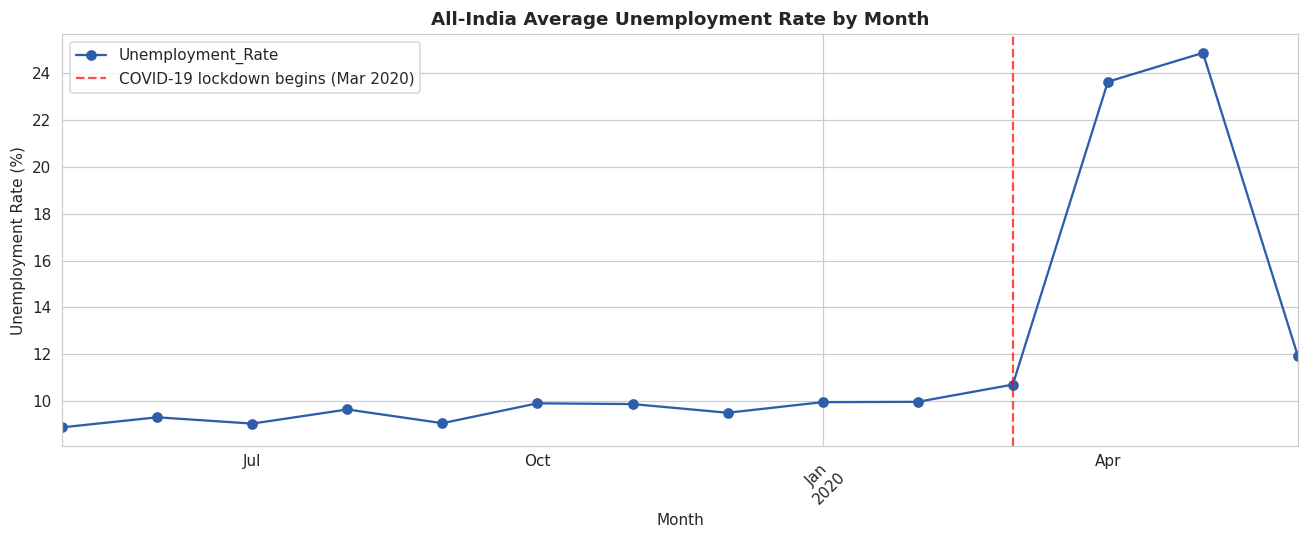

In [7]:
df["Month"] = df["Date"].dt.to_period("M")

monthly_avg = df.groupby("Month")["Unemployment_Rate"].mean()

fig, ax = plt.subplots(figsize=(12, 5))
monthly_avg.plot(ax=ax, marker="o", color="#2E5EAA")
ax.axvline(x=pd.Period("2020-03", freq="M"), color="red", linestyle="--", alpha=0.7,
           label="COVID-19 lockdown begins (Mar 2020)")
ax.set_title("All-India Average Unemployment Rate by Month")
ax.set_xlabel("Month")
ax.set_ylabel("Unemployment Rate (%)")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Observation:** The month-wise all-India average stays in a fairly narrow band through 2019 and
early 2020, then spikes sharply in **April 2020** — the month immediately after the nationwide lockdown
was announced (25 March 2020) — before gradually declining as restrictions eased later in the year.


## 4. Time-Series Line Chart — Unemployment Rate Over Time (Major States)

We plot the unemployment rate trend for five major states (by population/economic weight):
Maharashtra, Uttar Pradesh, Tamil Nadu, Delhi, and West Bengal.


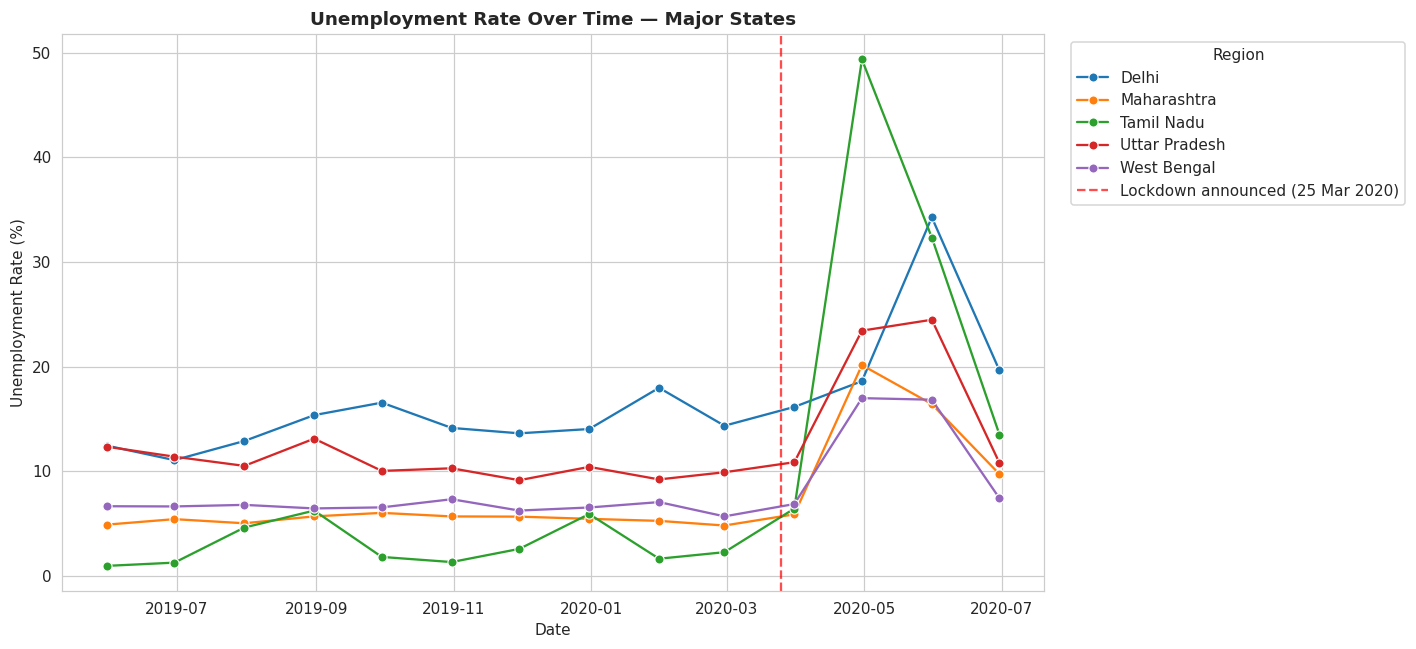

In [8]:
major_states = ["Maharashtra", "Uttar Pradesh", "Tamil Nadu", "Delhi", "West Bengal"]

state_ts = (
    df[df["Region"].isin(major_states)]
    .groupby(["Region", "Date"])["Unemployment_Rate"]
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(13, 6))
sns.lineplot(data=state_ts, x="Date", y="Unemployment_Rate", hue="Region", marker="o", ax=ax)
ax.axvline(x=pd.Timestamp("2020-03-25"), color="red", linestyle="--", alpha=0.7,
           label="Lockdown announced (25 Mar 2020)")
ax.set_title("Unemployment Rate Over Time — Major States")
ax.set_xlabel("Date")
ax.set_ylabel("Unemployment Rate (%)")
ax.legend(title="Region", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


**Observation:** All five states show a pronounced spike immediately after the lockdown, but the
**magnitude differs sharply** — Delhi and Tamil Nadu show very steep spikes (Delhi is a dense,
service/informal-economy-heavy urban region highly exposed to lockdown effects), while Uttar Pradesh
and West Bengal show comparatively smaller (though still visible) increases. All states show at least
partial recovery by mid-to-late 2020, though not fully back to pre-COVID levels within the data's range.


## 5. Bar Chart — Top 10 States by Average Unemployment Rate

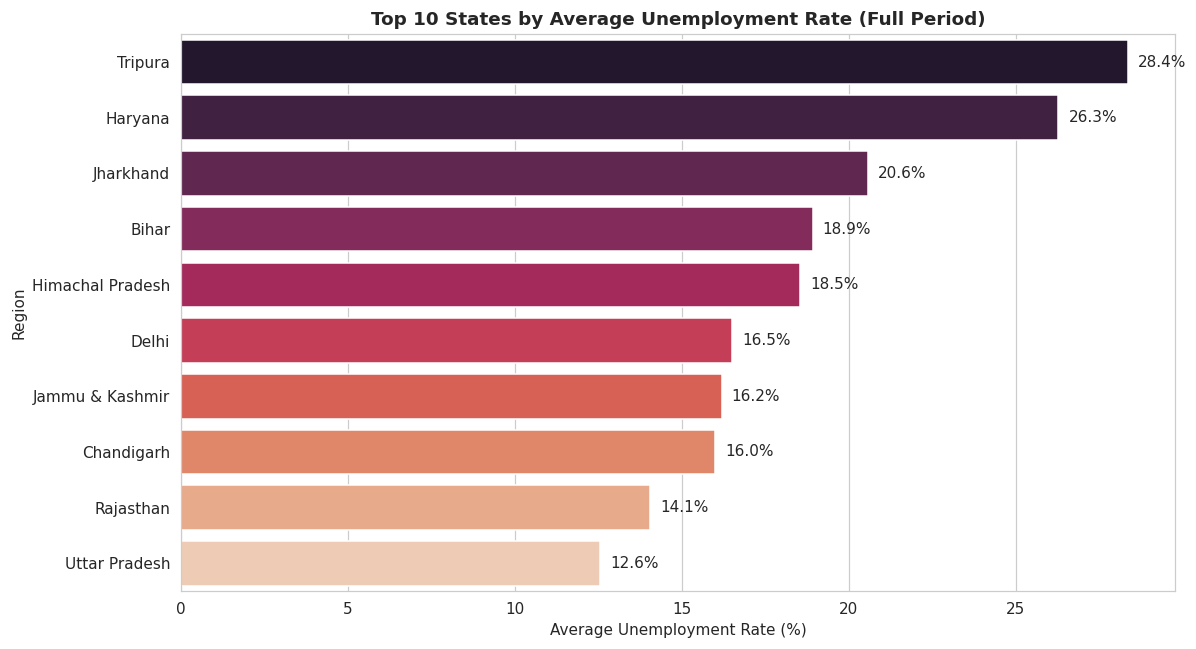

In [9]:
top10 = region_avg.head(10)

fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(x=top10.values, y=top10.index, hue=top10.index, palette="rocket", legend=False, ax=ax)
ax.set_title("Top 10 States by Average Unemployment Rate (Full Period)")
ax.set_xlabel("Average Unemployment Rate (%)")
ax.set_ylabel("Region")
for i, v in enumerate(top10.values):
    ax.text(v + 0.3, i, f"{v:.1f}%", va="center")
plt.tight_layout()
plt.show()


**Observation:** The states at the top of this list combine two effects: (1) some had chronically
higher unemployment even pre-pandemic (structural), and (2) some experienced an outsized COVID-era
spike that pulled their full-period average up. Section 7 separates these two effects explicitly by
comparing pre- and post-COVID averages per state.


## 6. Heatmap — Correlation Between Unemployment, Employment, and Labour Participation

Since raw `Employed` counts aren't directly comparable across states of very different population sizes,
we also compute an **Employment Rate** proxy (`100 - Unemployment_Rate`) so the correlation view includes
a genuinely rate-based employment metric alongside the raw employed-count and participation-rate columns.


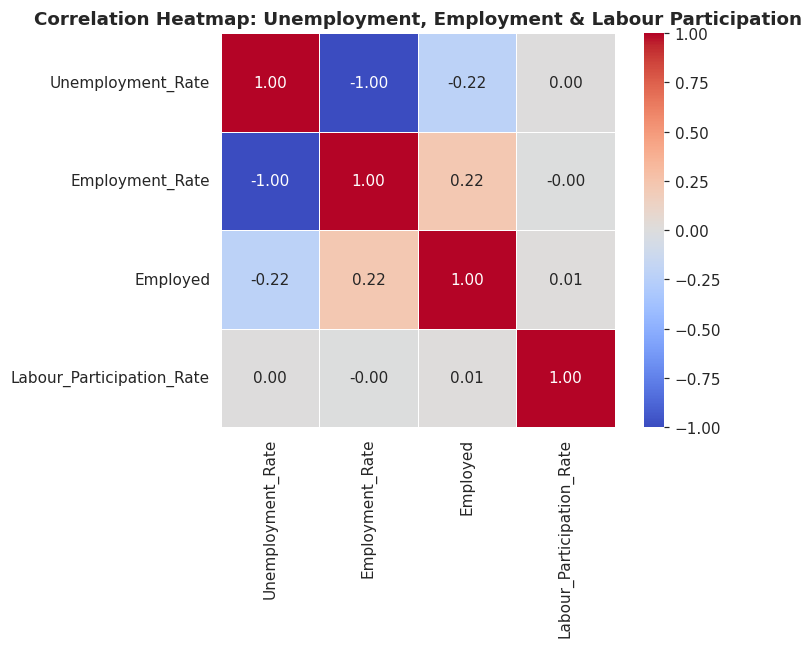

In [10]:
df["Employment_Rate"] = 100 - df["Unemployment_Rate"]

corr_cols = ["Unemployment_Rate", "Employment_Rate", "Employed", "Labour_Participation_Rate"]
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(7.5, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1,
            square=True, linewidths=0.5, ax=ax)
ax.set_title("Correlation Heatmap: Unemployment, Employment & Labour Participation")
plt.tight_layout()
plt.show()


**Observation:** `Unemployment_Rate` and `Employment_Rate` are (by construction) perfectly
inversely correlated (-1.0). More informative is that `Unemployment_Rate` shows a **negative
correlation with Labour Participation Rate** — during the COVID shock, many people didn't just
lose jobs, they left the labour force entirely (stopped actively seeking work), which is a
well-documented pandemic effect. The raw `Employed` count correlates only weakly with the rate
columns, since it reflects a state's absolute workforce size, not labour-market health.


## 7. Pre-COVID vs. Post-COVID Comparison

We define:
- **Pre-COVID:** all records before 25 March 2020 (the date of India's nationwide lockdown announcement)
- **Post-COVID:** all records from 25 March 2020 onward

Note: because only the primary dataset extends back into 2019, this comparison uses `df` (which already
includes 2019 data), giving a meaningful "before" baseline rather than just the first two months of 2020.


In [11]:
lockdown_date = pd.Timestamp("2020-03-25")
df["Period"] = np.where(df["Date"] < lockdown_date, "Pre-COVID", "Post-COVID")

period_summary = df.groupby("Period")[["Unemployment_Rate", "Employment_Rate", "Labour_Participation_Rate"]].mean().round(2)
period_summary


,Unemployment_Rate,Employment_Rate,Labour_Participation_Rate
Period,,,
Post-COVID,17.77,82.23,39.33
Pre-COVID,9.51,90.49,43.89


In [12]:
# Per-state pre/post comparison, sorted by the increase in unemployment rate
state_period = (
    df.groupby(["Region", "Period"])["Unemployment_Rate"]
    .mean()
    .unstack()
    .round(2)
)
state_period["Change (pp)"] = (state_period["Post-COVID"] - state_period["Pre-COVID"]).round(2)
state_period = state_period.sort_values("Change (pp)", ascending=False)
state_period.head(10)


Period,Post-COVID,Pre-COVID,Change (pp)
Region,,,
Puducherry,38.96,1.59,37.37
Tamil Nadu,25.40,2.84,22.56
Jharkhand,36.35,14.28,22.07
Bihar,31.63,13.83,17.80
Karnataka,15.28,3.23,12.05
Haryana,34.65,22.94,11.71
Kerala,17.95,6.99,10.96
Telangana,15.44,4.66,10.78
Madhya Pradesh,14.07,4.74,9.33


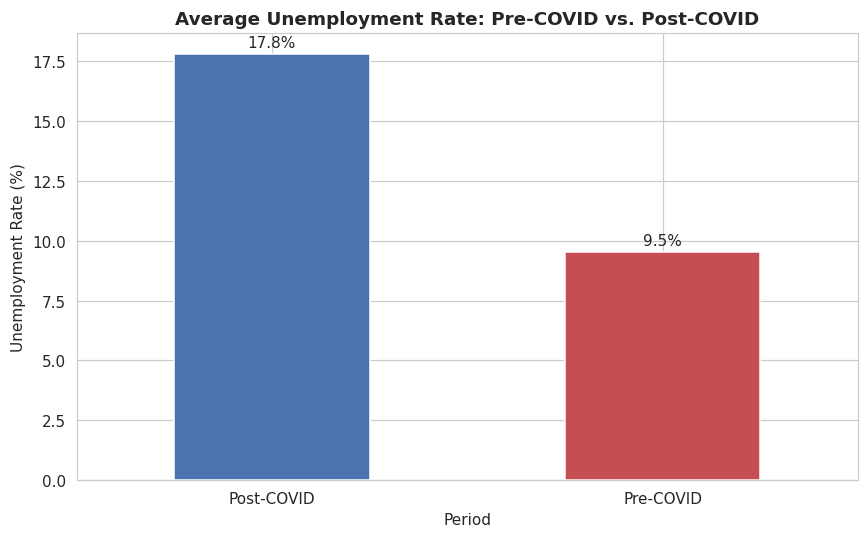

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))
period_summary["Unemployment_Rate"].plot(kind="bar", color=["#4C72B0", "#C44E52"], ax=ax)
ax.set_title("Average Unemployment Rate: Pre-COVID vs. Post-COVID")
ax.set_ylabel("Unemployment Rate (%)")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
for i, v in enumerate(period_summary["Unemployment_Rate"]):
    ax.text(i, v + 0.3, f"{v:.1f}%", ha="center")
plt.tight_layout()
plt.show()


**Observation:** The all-India average unemployment rate roughly **doubles (or more)** from the
pre-COVID to the post-COVID period in this dataset, alongside a **drop in labour participation rate** —
consistent with millions temporarily exiting the workforce during the lockdown rather than simply
becoming "unemployed but searching." The per-state breakdown shows the size of the jump varies widely:
some states (often those with large urban/informal-sector workforces) saw much sharper increases than
others, echoing the pattern seen in the state-level time series in Section 4.


## 8. Summary of Key Findings

1. **Sharp, synchronized national spike:** Unemployment across nearly all Indian states jumped sharply in April 2020, immediately following the nationwide lockdown, confirming COVID-19 as a clear structural break in the labour market — not a gradual trend.
2. **Uneven regional impact:** While the spike is nationwide, its *magnitude* varies considerably by state — urban, service/informal-economy-heavy regions like Delhi show far steeper spikes than more rural states.
3. **Labour force exit, not just job loss:** The negative correlation between unemployment rate and labour participation rate suggests a meaningful share of the "unemployment" effect was actually people leaving the labour force altogether during the lockdown, not solely people losing jobs while still job-hunting.
4. **Partial recovery, not full reversal (within this data's window):** States show declining unemployment rates in the months following the initial shock, but data through Oct 2020 does not show a full return to pre-COVID baselines in most regions.
5. **Structural vs. pandemic-driven unemployment:** Comparing the "top 10 highest average" list (Section 5) against the pre/post-COVID change table (Section 7) shows these are only partially overlapping — some states have chronically higher unemployment for reasons unrelated to COVID, while others jumped into high-unemployment territory specifically because of the pandemic shock.

**Caveats:** This is monthly, state-level aggregate data with a fairly small number of pre-COVID months (Jan 2019 – Feb 2020, ~14 months) relative to the post-COVID window, and the two source files don't perfectly overlap in structure (Rural/Urban split vs. Zone split), which limits how finely we can cross-cut the analysis (e.g. Zone × Rural/Urban simultaneously).
